# NorESM CCN–CDNC Susceptibility by Supersaturation

**Scientific question:** How sensitive is cloud droplet number concentration (CDNC) to cloud condensation nuclei (CCN) when CCN is resolved by *supersaturation level* (0.02–1.0 %) rather than by activation cutoff radius — and how does that susceptibility vary across stations, vertical levels, and regression estimator (OLS vs total-least-squares / Deming / PCA)?

Susceptibility is the slope d ln(CDNC) / d ln(CCN). The model output carries CCN at seven prescribed supersaturations (`CCN1`…`CCN7`), which are stacked into a single `supersaturation` dimension. For each station the slope is computed two ways: **per vertical level** (one slope per level, regressing over time) and **all-levels pooled** (one slope per supersaturation, with levels and time flattened together). Four estimators run side-by-side because OLS is biased low when the predictor (CCN) carries sampling noise, so the error-in-variables fits (TLS/Deming/PCA) bracket the true slope.

A separate **binned** builder (`build_susceptibility_dataset_by_station`) fits one slope per supersaturation on median-per-bin points in log–log space. Section 6 compares that binned slope against the simple all-level pooled OLS, per station.

**Input:** per-station NorESM/OsloAero file on `/share/sabl0586/…_4Peter.nc` (15 stations; CDNC, the seven CCN supersaturation bins, `FREQL`, `Z3`).
**Output:** in-memory `Susceptibility_all` and `reg_ds_binned`, plus diagnostic plots.

## 1 · Setup and imports

`PeterChurchillFunctions` (imported as `Function`) provides the estimators (`OLS_fit`, `TLS_fit`, `deming_fit`, `PCA_fit`), the NorESM extractor `NorESMExtract_Dask`, the two susceptibility builders (`susceptibility_by_level`, `compute_allLev`), the binned builder `build_susceptibility_dataset_by_station`, and the plotting helper `plot_hexbin_regression_multi`.

In [1]:
# --- Imports ---
import PeterChurchillFunctions as Function
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import erf
import statsmodels.api as sm
from scipy.odr import ODR, Model, RealData
from matplotlib.colors import LogNorm

# --- Configuration (single source of truth) ---
# Per-station NorESM/OsloAero output (15 stations; dims: station, time, lev).
NOR_PATH = "/share/sabl0586/all_stations_NorESM_OsloAero_prcp2szdst_f19_f19_noresmv211_corr_ilevall_levs_4Peter.nc"

# The seven prescribed CCN supersaturations (%), matching CCN1..CCN7 in the file.
SUPERSATURATIONS = [0.02, 0.05, 0.10, 0.15, 0.20, 0.50, 1.00]

# Variables pulled per station by the extractor.
VAR_LIST = ['Z3', 'FREQL', 'CCN1', 'CCN2', 'CCN3', 'CCN4', 'CCN5', 'CCN6', 'CCN7']

# Only liquid-cloud columns enter the CDNC regression.
FREQL_THRESHOLD = 0.8

# Diameter grid for the size-distribution machinery inside the extractor (log-spaced, nm).
D_GRID = xr.DataArray(
    np.logspace(-0.5, 3, num=200),
    dims=['D'],
    coords={'D': np.logspace(-0.5, 3, num=200)},
)

## 2 · Susceptibility builders (from `PeterChurchillFunctions`)

The per-level and all-level pooled builders now live in the module so this notebook and the radius-based notebook share one implementation. Both accept `bin_dim`, which we set to `'supersaturation'` here (it defaults to `'radius'` for the cutoff-radius notebooks):

- `Function.susceptibility_by_level(CCN, CDNC, bin_dim='supersaturation')` → slope/intercept on `(supersaturation, lev)`, regressing over **time**, plus the aligned CCN/CDNC pair for plotting. *(Note: this builder labels the total-least-squares fit `'ODR'`, e.g. `'ODR slope'`.)*
- `Function.compute_allLev(CCN, CDNC, bin_dim='supersaturation')` → one slope/intercept per `supersaturation` (levels + time flattened), variables prefixed `All_Level_` and labelled `TLS`.

## 3 · Load the NorESM dataset

Open lazily (`chunks={}` keeps it dask-backed) and read off the station list.

In [2]:
ds = xr.open_dataset(NOR_PATH, chunks={})
stations = ds["station"].values

## 4 · Build susceptibility across all stations

For each station: extract the variables, stack `CCN1`…`CCN7` into a `supersaturation` dimension, mask CDNC to liquid-cloud columns (`FREQL > FREQL_THRESHOLD`), then run both module builders and merge. Results are tagged with a `station` coord and concatenated. The mean geopotential height `Z3` is retained per station for the height plots.

*(This is the expensive cell — collapse it once it has run.)*

In [3]:
all_stations = []
all_stationsCCN = []
all_stationsHeight = []

for station in stations:
    Nor_ds = Function.NorESMExtract_Dask(NOR_PATH, station, VAR_LIST, D_GRID, PNSD=False)

    # Stack the seven CCN supersaturation bins into one dimension.
    CCN_xr = (
        Nor_ds[['CCN1', 'CCN2', 'CCN3', 'CCN4', 'CCN5', 'CCN6', 'CCN7']]
        .to_array(dim='supersaturation')
        .assign_coords(supersaturation=SUPERSATURATIONS)
        .rename('CCN')
    )
    CCN_xr.attrs['long_name'] = 'Cloud Condensation Nuclei concentration'
    CCN_xr.attrs['units'] = 'cm-3'
    CCN_xr['supersaturation'].attrs['units'] = '%'

    height = Nor_ds['Z3'].mean('time')
    CDNC_masked = Nor_ds['CDNC'].where(Nor_ds['FREQL'] > FREQL_THRESHOLD)

    Level_susc_ds, Levels_CCN_ds = Function.susceptibility_by_level(
        CCN_xr, CDNC_masked, bin_dim='supersaturation'
    )
    Susceptibility_AllLevs = Function.compute_allLev(
        CCN_xr, CDNC_masked, bin_dim='supersaturation'
    )
    Susceptibility_ds = xr.merge([Level_susc_ds, Susceptibility_AllLevs])

    all_stations.append(Susceptibility_ds.assign_coords(station=station))
    all_stationsCCN.append(Levels_CCN_ds.assign_coords(station=station))
    all_stationsHeight.append(height.assign_coords(station=station))

# Concatenate across stations.
Susceptibility_all = xr.concat(all_stations, dim='station')
CCN_all = xr.concat(all_stationsCCN, dim='station')
Height_all = xr.concat(all_stationsHeight, dim='station')

## 5 · Binned susceptibility per station

Force the lazy CCN/CDNC pair into memory, then build the equal-count binned susceptibility dataset with `build_susceptibility_dataset_by_station` (no updraft stratification here — `updraft_ds=None`). This fits one slope per supersaturation on median-per-bin points, and returns `slope`, `intercept`, `r_value`, `std_err`.

In [ ]:
CCN_all = CCN_all.compute()
reg_ds_binned = Function.build_susceptibility_dataset_by_station(
    CCN_all, SUPERSATURATIONS,
    bin_dim='supersaturation',
    updraft_ds=None,
    Binning='Equal Number',
)

/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


Processing station: ZEP (1/15)
Processing station: SMR-II (2/15)
Processing station: ATTO (3/15)
Processing station: MHD (4/15)
Processing station: SGP (5/15)
Processing station: CHC (6/15)
Processing station: BIR-II (7/15)
Processing station: PAL (8/15)
Processing station: Vavihill (9/15)
Processing station: JFJ (10/15)
Processing station: FKL (11/15)
Processing station: SMEAR-I (12/15)
Processing station: Villum (13/15)
Processing station: Izana (14/15)
Processing station: Maldives (15/15)


/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_e

## 6 · Binned vs simple pooled OLS, per station

The two methods estimate the same quantity — susceptibility as a function of supersaturation — but differ in how they treat the raw cloud of (CCN, CDNC) points:

- **Pooled OLS** (`All_Level_OLS_slope`) fits every raw point in log–log space at once. It is biased low wherever the point density is uneven or CCN carries sampling noise (regression dilution).
- **Binned** (`reg_ds_binned.slope`) first reduces the cloud to one median point per equal-count CCN bin, then fits those medians. Binning suppresses the leverage of dense low-CCN regions, so it often sits above the pooled OLS slope.

Each panel overlays both for one station. Where the binned curve lifts above OLS is where the raw-point fit is being dragged down by point density.

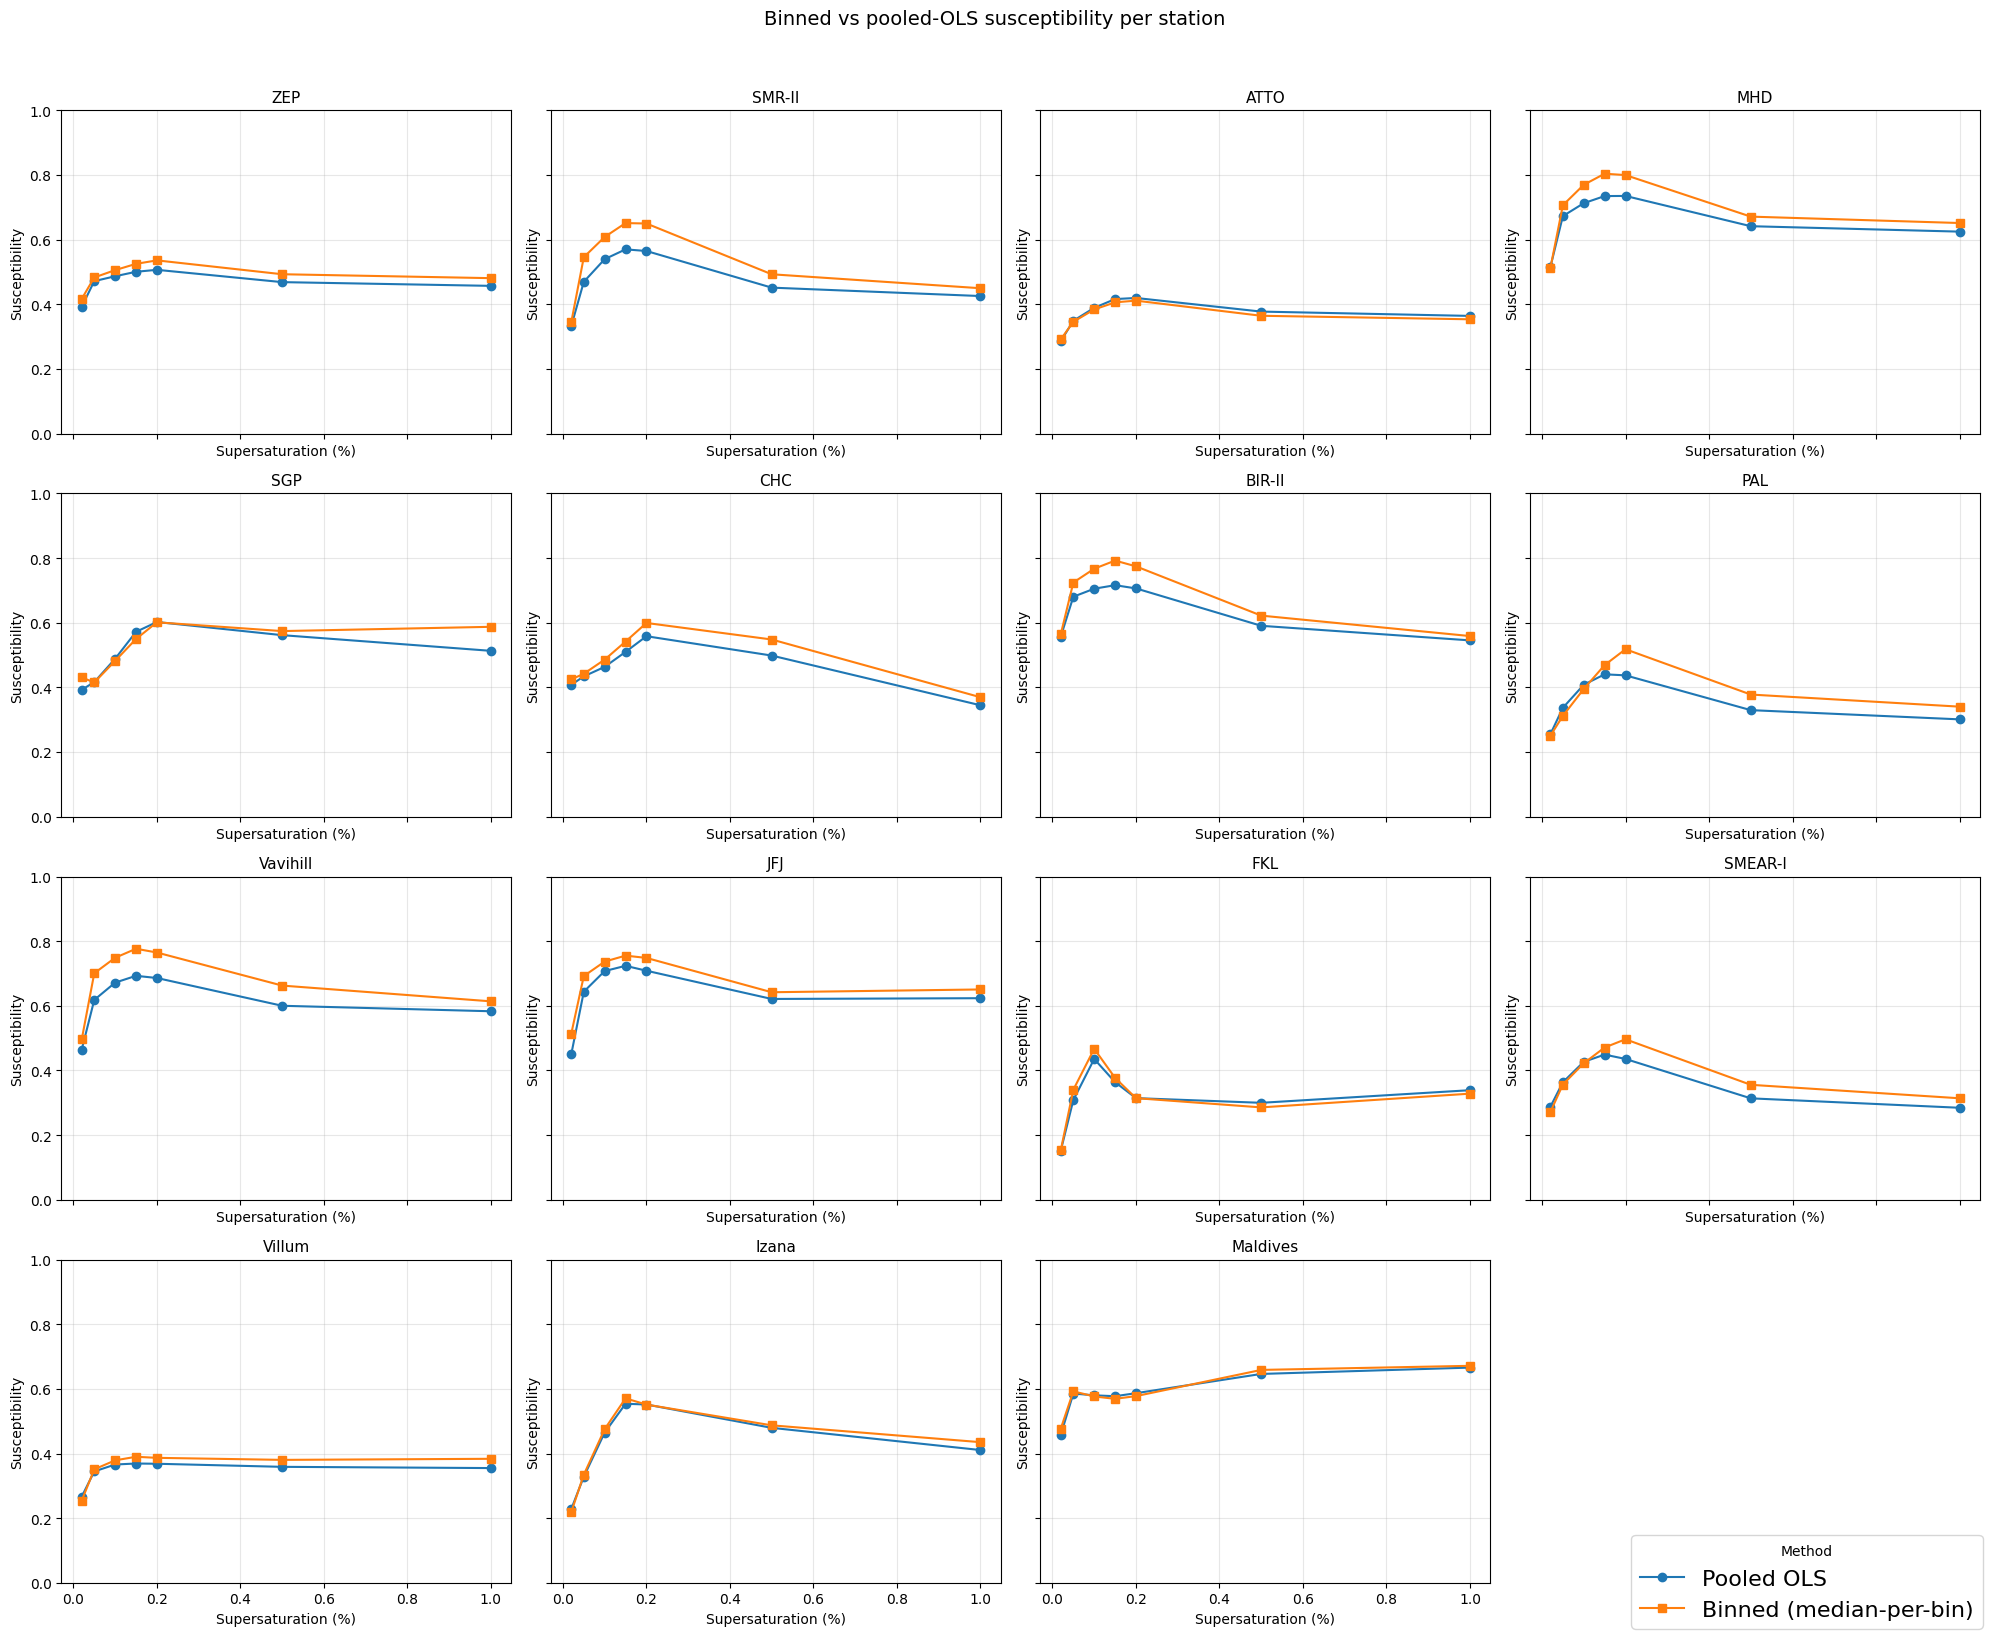

In [5]:
ncols = 4
nrows = int(np.ceil(len(stations) / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows),
                         sharex=True, sharey=True)
axes = axes.flatten()

for i, station in enumerate(stations):
    ax = axes[i]
    ols = Susceptibility_all['All_Level_OLS_slope'].sel(station=station)
    binned = reg_ds_binned['slope'].sel(station=station)

    ax.plot(SUPERSATURATIONS, ols, marker='o', label='Pooled OLS')
    ax.plot(SUPERSATURATIONS, binned, marker='s', label='Binned (median-per-bin)')

    ax.set_title(f"{station}", fontsize=11)
    ax.set_xlabel("Supersaturation (%)")
    ax.set_ylabel("Susceptibility")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

for j in range(len(stations), len(axes)):
    axes[j].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Method", loc="lower right", fontsize=16)
fig.suptitle("Binned vs pooled-OLS susceptibility per station", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [15]:
reg_ds_binned 


<xarray.Dataset> Size: 4kB
Dimensions:          (station: 15, supersaturation: 7)
Coordinates:
  * station          (station) <U8 480B 'ZEP' 'SMR-II' ... 'Izana' 'Maldives'
  * supersaturation  (supersaturation) float64 56B 0.02 0.05 0.1 ... 0.2 0.5 1.0
Data variables:
    slope            (station, supersaturation) float64 840B 0.4172 ... 0.6713
    r_value          (station, supersaturation) float64 840B 0.9802 ... 0.9572
    std_err          (station, supersaturation) float64 840B 0.008513 ... 0.0...
    intercept        (station, supersaturation) float64 840B 1.463 ... 0.08269

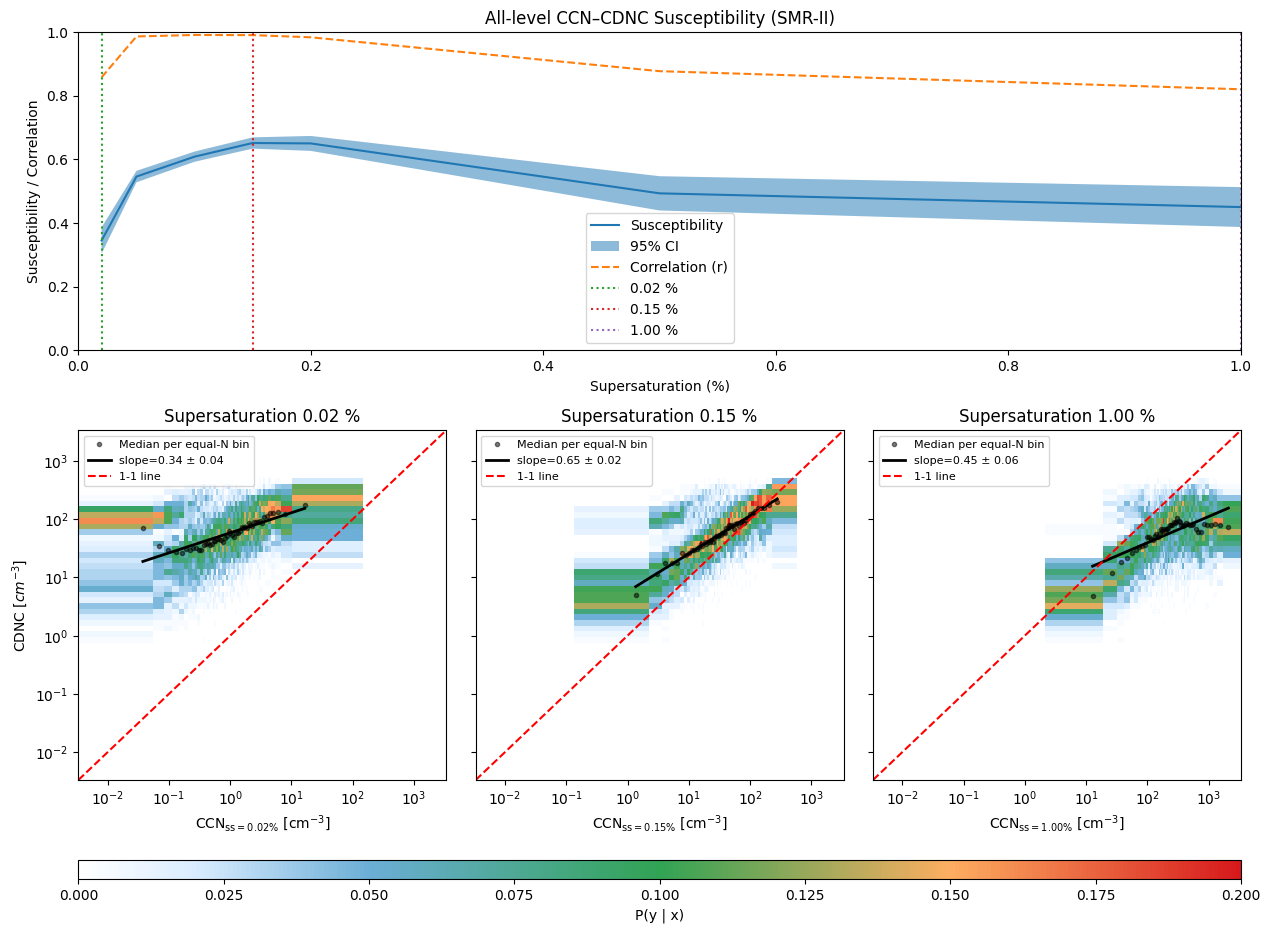

In [29]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, MaxNLocator

cmap = LinearSegmentedColormap.from_list(
    "paper_style",
    [
        (0.0,  "#ffffff"),
        (0.1,  "#d9ecff"),
        (0.25, "#6baed6"),
        (0.5,  "#31a354"),
        (0.75, "#fdae61"),
        (1.0,  "#d7191c"),
    ],
)

st = 'SMR-II'
n_bins = 50
pow_fmt = FuncFormatter(lambda v, _: rf"$10^{{{int(v)}}}$")

# --- pick supersaturation indices from the susceptibility curve ---
slope_curve = reg_ds_binned['slope'].sel(station=st).values
ss = SUPERSATURATIONS

iss1= 0    # first supersaturation
issmax = int(np.nanargmax(reg_ds_binned['slope'].sel(station=st).values))     # nearest to max
iss7 = 6  # last supersaturation (1.0%)
panel_idxs = [iss1, issmax, iss7]

# --- precompute panel data + global axis range for shared axes ---
def panel_data(ridx):
    ccn  = CCN_all['CCN'].sel(station=st).isel(supersaturation=ridx).values.ravel()
    cdnc = CCN_all['CDNC'].sel(station=st).values.ravel()
    valid = np.isfinite(ccn) & np.isfinite(cdnc) & (ccn > 0) & (cdnc > 0)
    lx, ly = np.log10(ccn[valid]), np.log10(cdnc[valid])

    bins = np.unique(np.quantile(lx, np.linspace(0, 1, n_bins + 1)))
    lx_med, ly_med = [], []
    for b in range(len(bins) - 1):
        if b == len(bins) - 2:
            m = (lx >= bins[b]) & (lx <= bins[b+1])
        else:
            m = (lx >= bins[b]) & (lx < bins[b+1])
        if m.sum() >= 2:
            lx_med.append(np.median(lx[m]))
            ly_med.append(np.median(ly[m]))
    lx_med, ly_med = np.array(lx_med), np.array(ly_med)

    ybins = np.linspace(ly.min(), ly.max(), 30)
    H, xedges, yedges = np.histogram2d(lx, ly, bins=[bins, ybins])
    H_norm = np.nan_to_num(H / H.sum(axis=1, keepdims=True))

    return dict(
        lx=lx, ly=ly, lx_med=lx_med, ly_med=ly_med,
        xedges=xedges, yedges=yedges, H_norm=H_norm,
        slope=float(reg_ds_binned['slope'].sel(station=st).isel(supersaturation=ridx)),
        intercept=float(reg_ds_binned['intercept'].sel(station=st).isel(supersaturation=ridx)),
        std_err=float(reg_ds_binned['std_err'].sel(station=st).isel(supersaturation=ridx)),
    )

pdata = [panel_data(r) for r in panel_idxs]

# global range across all panels so the 1-1 line stays diagonal everywhere
g_min = min(min(d['lx'].min(), d['ly'].min()) for d in pdata)
g_max = max(max(d['lx'].max(), d['ly'].max()) for d in pdata)

# --- layout ---
fig = plt.figure(figsize=(15, 11))
gs = fig.add_gridspec(3, 3, height_ratios=[1, 1.1, 0.06], hspace=0.35, wspace=0.08)

# top: susceptibility curve spanning all columns
ax_curve = fig.add_subplot(gs[0, :])
sl = reg_ds_binned['slope'].sel(station=st)
se = reg_ds_binned['std_err'].sel(station=st)
ax_curve.plot(ss, sl, label='Susceptibility')
ax_curve.fill_between(ss, sl - 1.98*se, sl + 1.98*se, alpha=0.5, label='95% CI')
ax_curve.plot(ss, reg_ds_binned['r_value'].sel(station=st), '--', label='Correlation (r)')
for ridx, c in zip(panel_idxs, ['tab:green', 'tab:red', 'tab:purple']):
    ax_curve.axvline(ss[ridx], color=c, linestyle=':', label=f'{ss[ridx]:.2f} %')
ax_curve.set_title(f"All-level CCN–CDNC Susceptibility ({st})")
ax_curve.set_xlabel('Supersaturation (%)')
ax_curve.set_ylabel('Susceptibility / Correlation')
ax_curve.set_ylim([0,1])
ax_curve.set_xlim([0, 1])
ax_curve.legend()

# bottom: three shared-axis joint-histogram panels
panel_axes = []
pcm = None
for col, (ridx, d) in enumerate(zip(panel_idxs, pdata)):
    sharex = panel_axes[0] if panel_axes else None
    ax = fig.add_subplot(gs[1, col], sharex=sharex, sharey=sharex)
    panel_axes.append(ax)

    pcm = ax.pcolormesh(d['xedges'], d['yedges'], d['H_norm'].T,
                        cmap=cmap, shading="auto", vmin=0, vmax=0.2)
    ax.plot(d['lx_med'], d['ly_med'], "k.", alpha=0.5, label="Median per equal-N bin")
    xfit = np.array([d['lx_med'].min(), d['lx_med'].max()])
    ax.plot(xfit, d['intercept'] + d['slope'] * xfit, "k-", linewidth=2,
            label=f"slope={d['slope']:.2f} ± {1.98*d['std_err']:.2f}")
    ax.plot([g_min, g_max], [g_min, g_max], ls="--", c="red", label="1-1 line")

    ax.set_xlim(g_min, g_max)
    ax.set_ylim(g_min, g_max)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.xaxis.set_major_formatter(pow_fmt)
    ax.yaxis.set_major_formatter(pow_fmt)
    ax.set_xlabel(rf"CCN$_{{\mathrm{{ss}}={ss[ridx]:.2f}\%}}$ [cm$^{{-3}}$]")
    ax.set_title(f"Supersaturation {ss[ridx]:.2f} %")
    ax.legend(fontsize=8, loc='upper left')

    if col == 0:
        ax.set_ylabel("CDNC [$cm^{-3}$]")
    else:
        ax.tick_params(labelleft=False)  # hide y tick labels on shared panels

# horizontal colorbar under the three panels
cax = fig.add_subplot(gs[2, :])
fig.colorbar(pcm, cax=cax, orientation='horizontal', label="P(y | x)")

plt.show()

Quick numerical summary of the gap (binned − OLS), averaged over supersaturation, per station. Positive values mean binning lifts the slope above the raw-point OLS.

In [6]:
ols_all = Susceptibility_all['All_Level_OLS_slope']
binned_all = reg_ds_binned['slope']
diff = (binned_all - ols_all)

summary = xr.Dataset({
    'OLS_mean': ols_all.mean('supersaturation'),
    'binned_mean': binned_all.mean('supersaturation'),
    'mean_diff': diff.mean('supersaturation'),
})
summary.to_dataframe().sort_values('mean_diff', ascending=False)

,OLS_mean,binned_mean,mean_diff
station,,,
Vavihill,0.616713,0.680507,0.063794
SMR-II,0.479464,0.534960,0.055496
BIR-II,0.643202,0.686429,0.043227
MHD,0.662699,0.702300,0.039601
JFJ,0.639805,0.676974,0.037169
CHC,0.459737,0.487554,0.027817
ZEP,0.469472,0.491841,0.022370
PAL,0.358505,0.380513,0.022008
SMEAR-I,0.365892,0.383954,0.018062


## 7 · CDNC sample counts with height

Count of non-zero CDNC samples per level, plotted against mean station height — a quick check of where (vertically) the liquid-cloud signal actually lives.

In [7]:
cdnc = CCN_all['CDNC']
count_gt0 = (cdnc > 0).sum(dim='time')

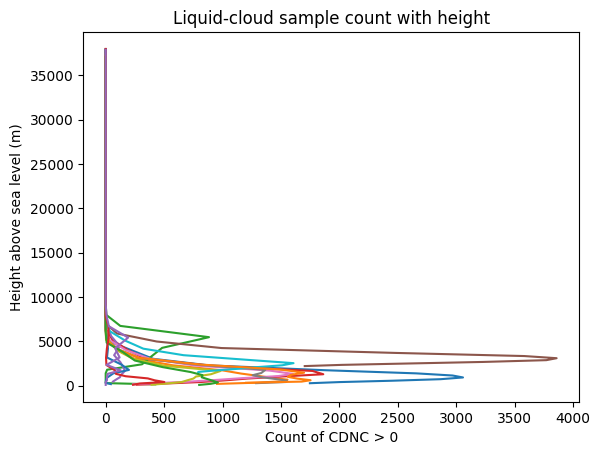

In [8]:
for station in stations:
    plt.plot(count_gt0.sel(station=station), Height_all.sel(station=station))
plt.xlabel("Count of CDNC > 0")
plt.ylabel("Height above sea level (m)")
plt.title("Liquid-cloud sample count with height")
plt.show()

## 8 · Per-level susceptibility profiles (all stations)

For each station, susceptibility vs height at every supersaturation. The y-limit is capped at the highest level where the OLS slope is still positive, so the profiles stay readable.

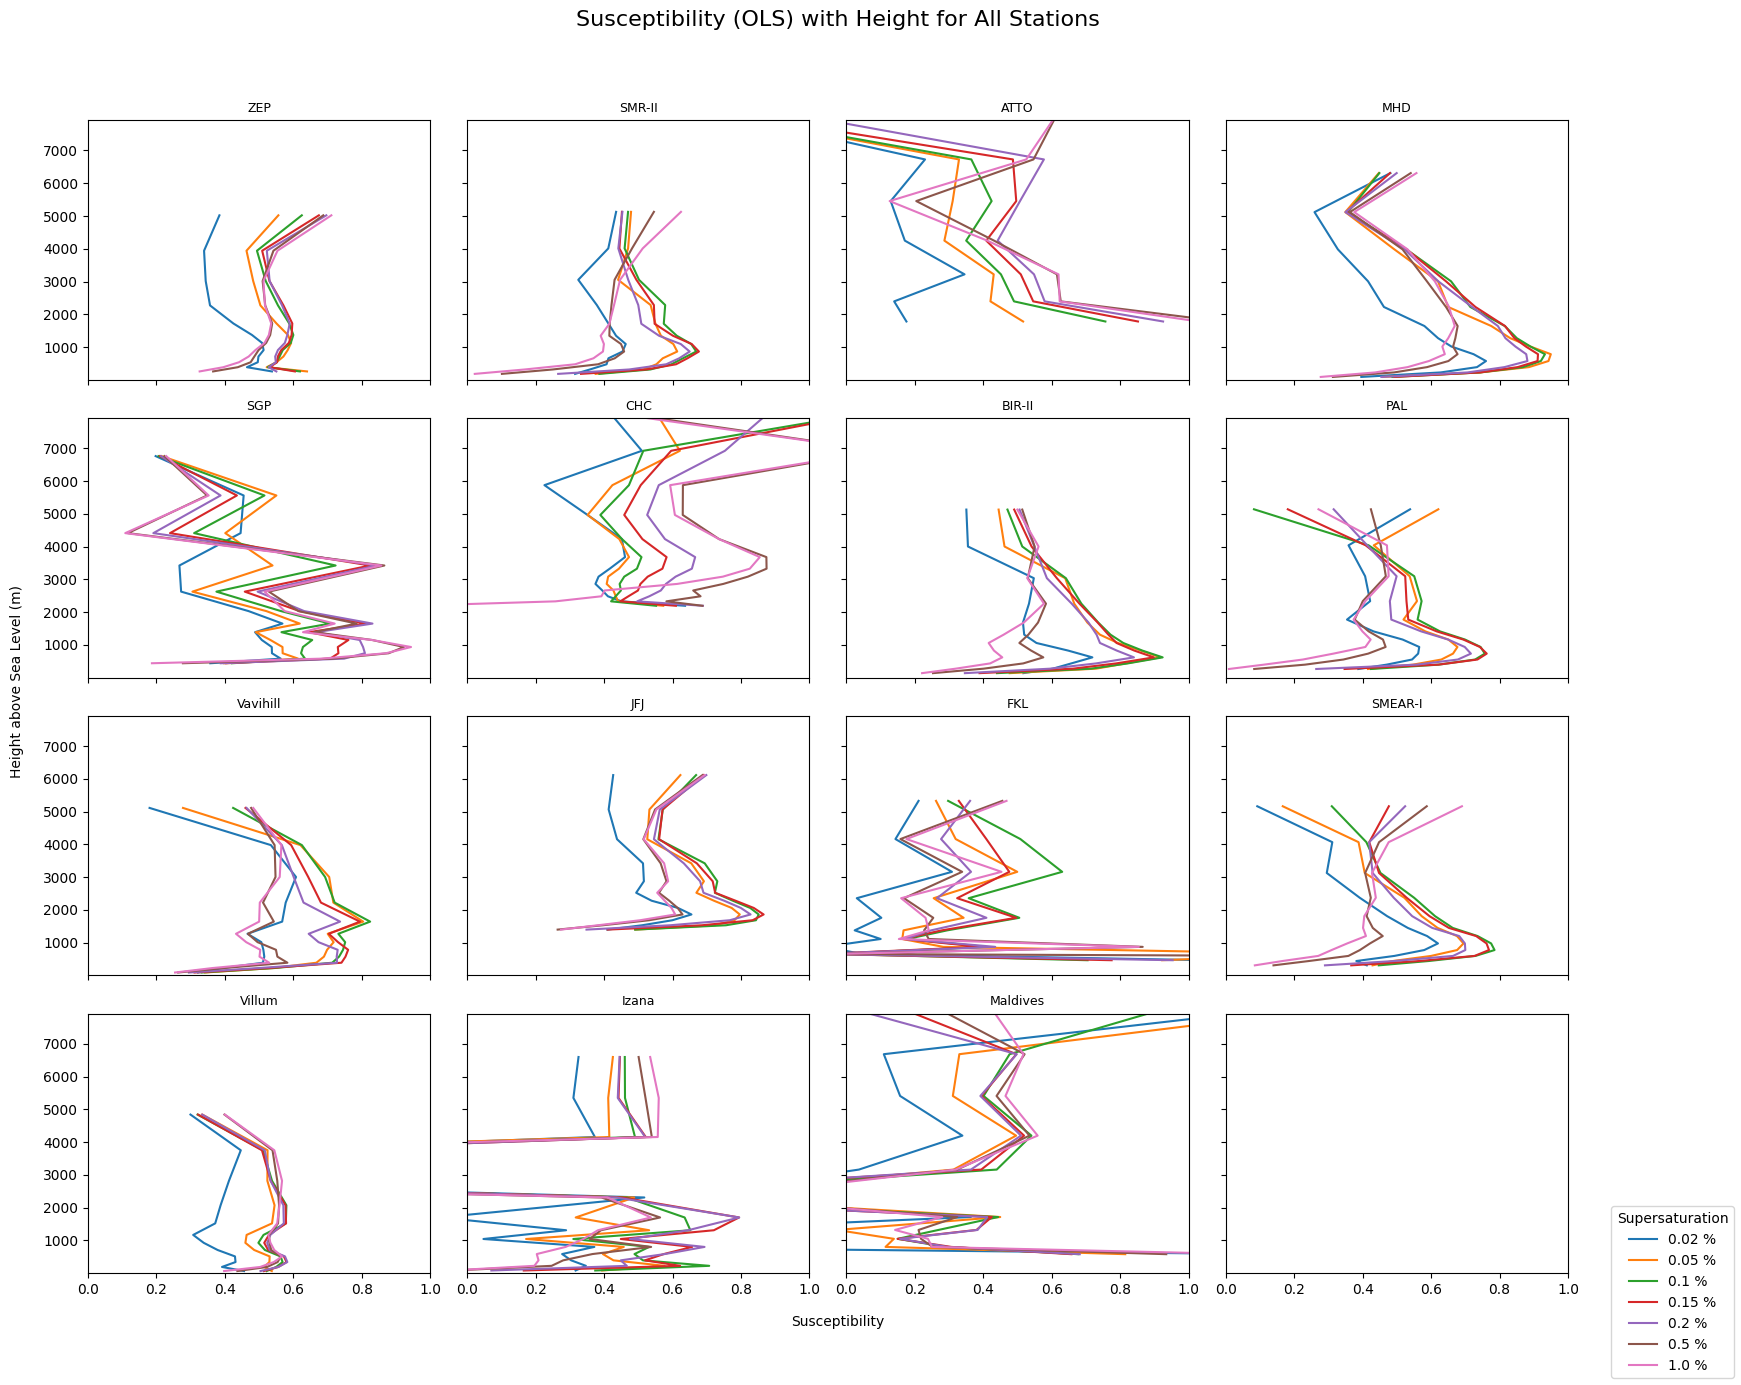

In [9]:
def SubPlotSusc_by_Level(ax, ds=None, Fit='OLS', station='SMR-II'):
    if ds is None:
        ds = Susceptibility_all
    yvals = Height_all.sel(station=station)

    for S in SUPERSATURATIONS:
        xvals = ds[f'{Fit} slope'].sel(supersaturation=S, station=station)
        ax.plot(xvals, yvals, label=f'{S} %')

    Max = float(
        Height_all.sel(station=station)
        .where(ds[f'{Fit} slope'].sel(supersaturation=S, station=station) > 0)
        .max()
    )
    ax.set_xlim(0, 1)
    ax.set_ylim(1, Max)
    ax.set_title(station, fontsize=9)


fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(18, 14), sharex=True, sharey=True)
axes = axes.flatten()

for ax, station in zip(axes, stations):
    SubPlotSusc_by_Level(ax, Susceptibility_all, Fit='OLS', station=station)

fig.text(0.5, 0.04, "Susceptibility", ha='center')
fig.text(0.04, 0.5, "Height above Sea Level (m)", va='center', rotation='vertical')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Supersaturation", loc="lower right")
fig.suptitle("Susceptibility (OLS) with Height for All Stations", fontsize=16)
fig.tight_layout(rect=[0.05, 0.05, 0.92, 0.95])
plt.show()

## 9 · All-level susceptibility vs supersaturation (estimator comparison)

One panel per station, each showing the all-levels-pooled slope across supersaturation for all four estimators. Where OLS sits below the error-in-variables fits is where regression dilution is strongest. *(The pooled builder labels TLS as `TLS`, unlike the per-level builder which uses `ODR`.)*

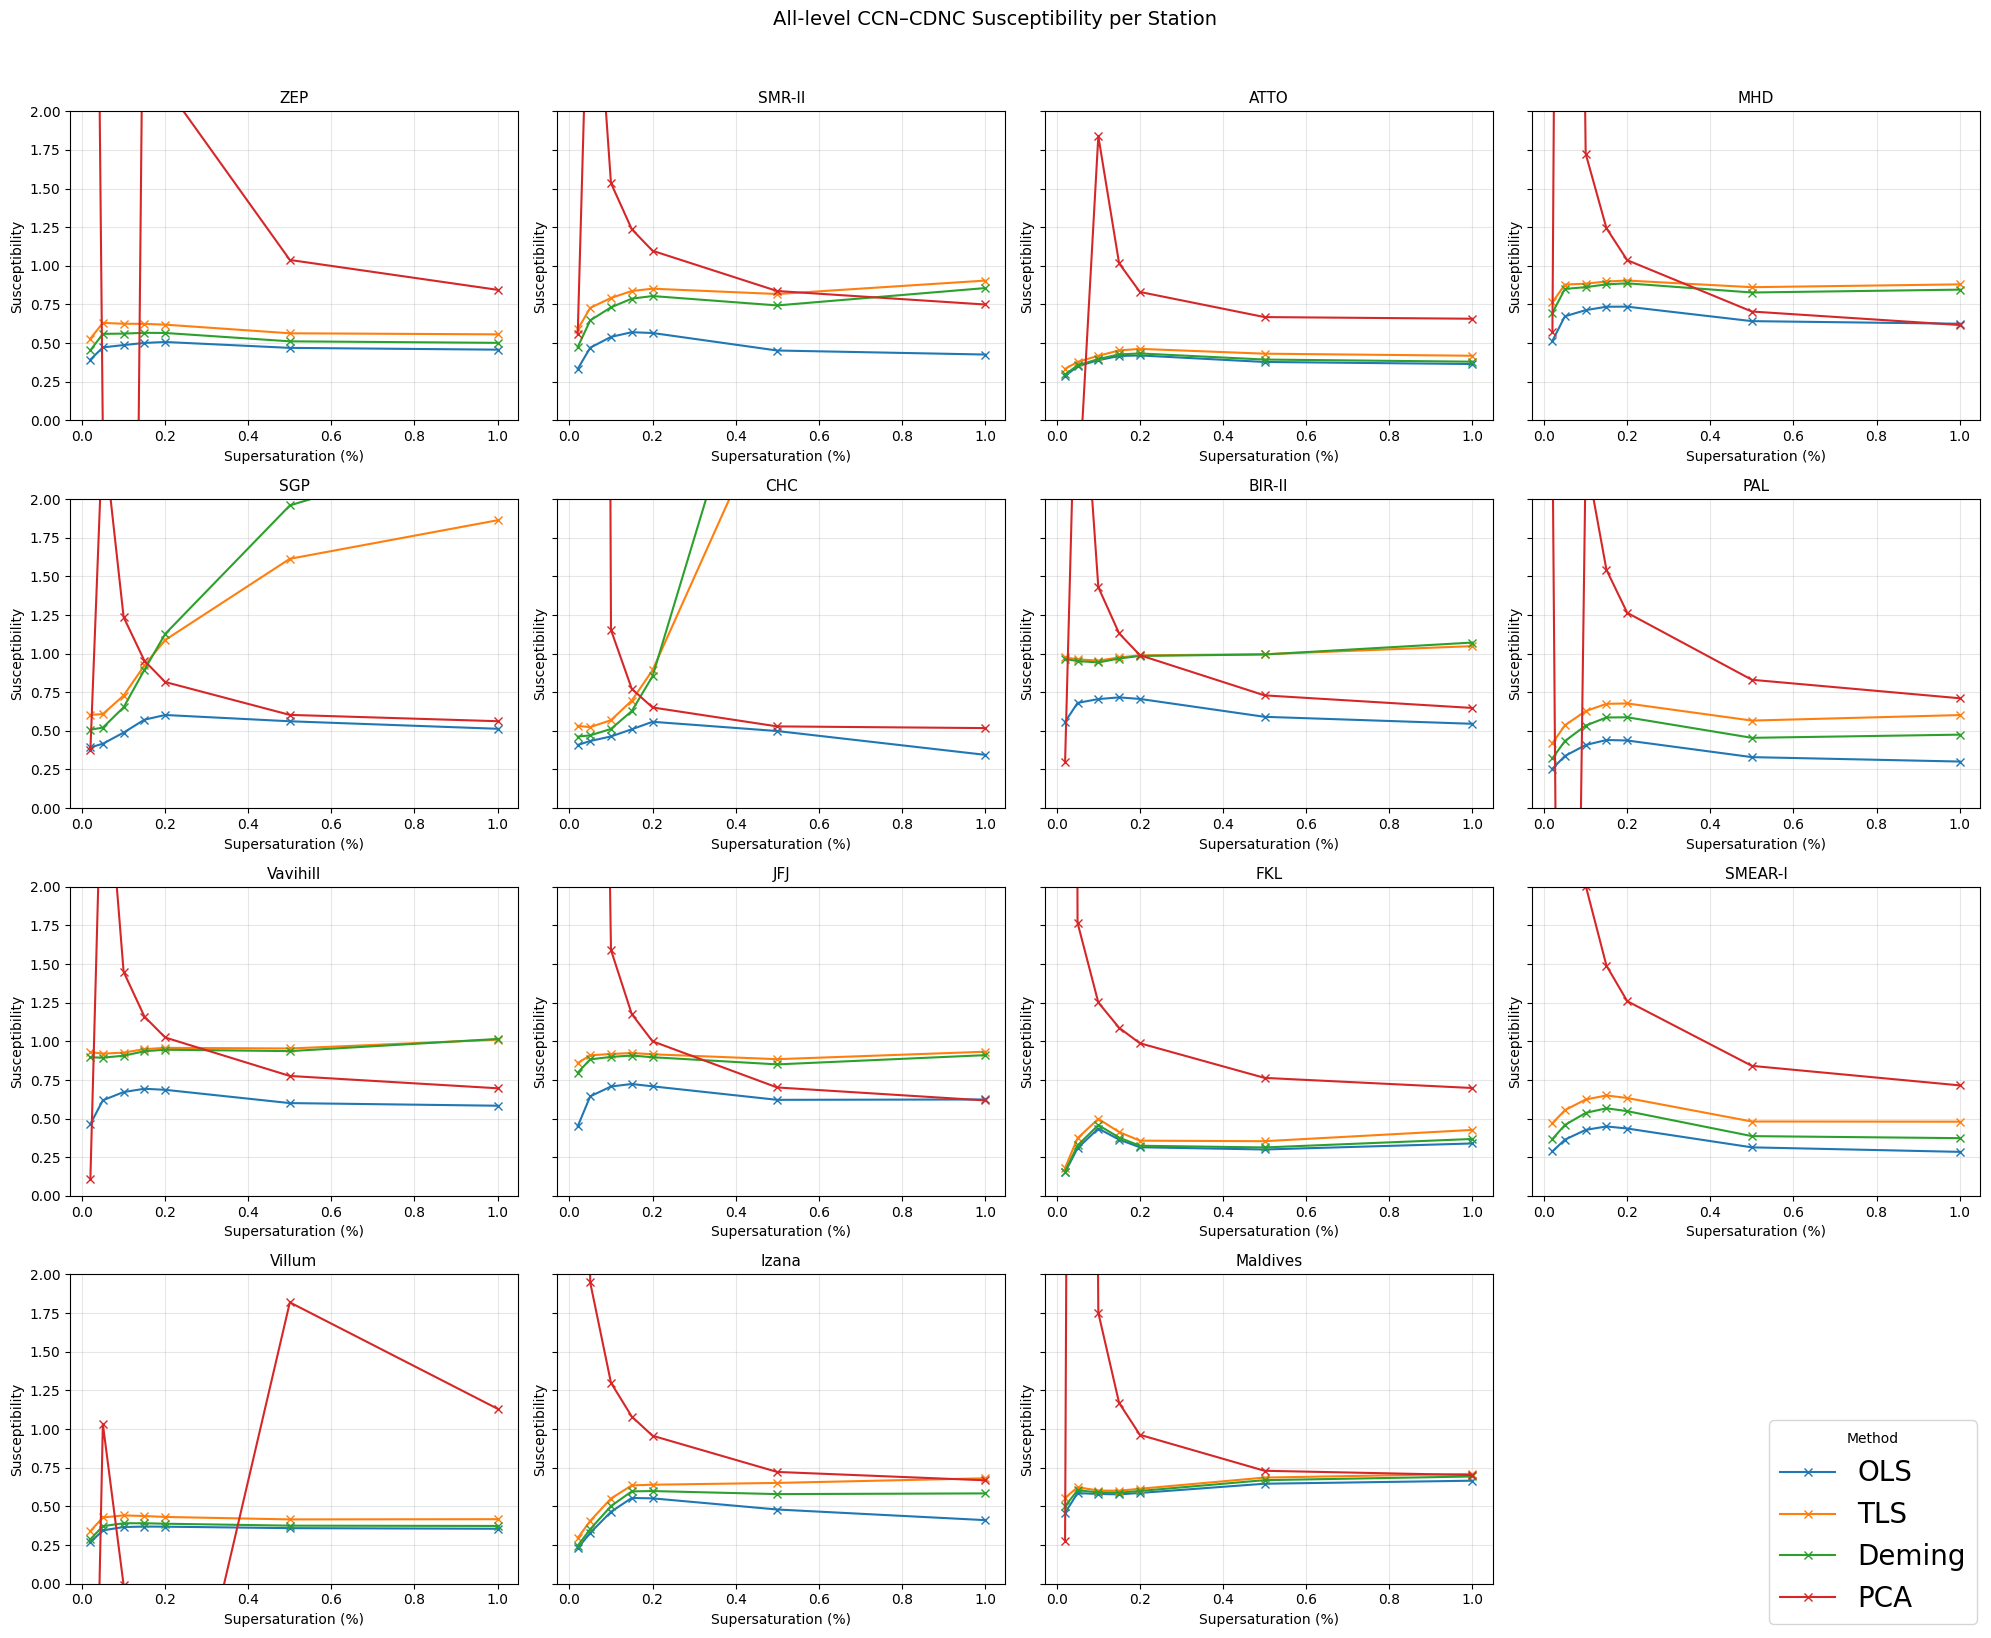

In [10]:
methods = ["OLS", "TLS", "Deming", "PCA"]
ncols = 4
nrows = int(np.ceil(len(stations) / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows), sharey=True)
axes = axes.flatten()

for i, station in enumerate(stations):
    ax = axes[i]
    for method in methods:
        var_name = f"All_Level_{method}_slope"
        if var_name in Susceptibility_all:
            Susceptibility_all[var_name].sel(station=station).plot(ax=ax, marker='x', label=method)
    ax.set_title(f"{station}", fontsize=11)
    ax.set_xlabel("Supersaturation (%)")
    ax.set_ylabel("Susceptibility")
    ax.set_ylim(0, 2)
    ax.grid(True, alpha=0.3)

for j in range(len(stations), len(axes)):
    axes[j].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Method", loc="lower right", fontsize=20)
fig.suptitle("All-level CCN–CDNC Susceptibility per Station", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 10 · Per-station log–log fits

For a chosen supersaturation, overlay the four precomputed fits on the CCN–CDNC scatter (hexbin) for each station. No refitting happens here — slopes/intercepts are read straight from `Susceptibility_all`.

In [11]:
def plot_station_fits_from_dataset(Susceptibility_all, station, supersaturation=0.15, methods=None):
    """Plot CDNC vs CCN (log-log) with the precomputed all-level fits overlaid."""
    if methods is None:
        methods = ["OLS", "TLS", "Deming", "PCA"]

    x = CCN_all['CCN'].sel(supersaturation=supersaturation, station=station).to_numpy().ravel()
    y = CCN_all["CDNC"].sel(station=station).to_numpy().ravel()

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x, y = x[mask], y[mask]

    styles = {"OLS": "r-", "TLS": "g--", "Deming": "b-.", "PCA": "m:"}
    fits = []
    for method in methods:
        slope_var = f"All_Level_{method}_slope"
        intercept_var = f"All_Level_{method}_intercept"
        if slope_var in Susceptibility_all and intercept_var in Susceptibility_all:
            slope = Susceptibility_all[slope_var].sel(station=station, supersaturation=supersaturation).compute().item()
            intercept = Susceptibility_all[intercept_var].sel(station=station, supersaturation=supersaturation).compute().item()
            fits.append({
                "slope": slope,
                "intercept": intercept,
                "label": f"{method}: slope={slope:.2f}",
                "style": styles.get(method, "k-"),
            })

    fig, ax = Function.plot_hexbin_regression_multi(
        x, y, fits=fits, lims=(1, 1e4),
        title=f"{station}: CCN–CDNC Fits (supersaturation={supersaturation}%)",
    )
    plt.tight_layout()
    return fig, ax

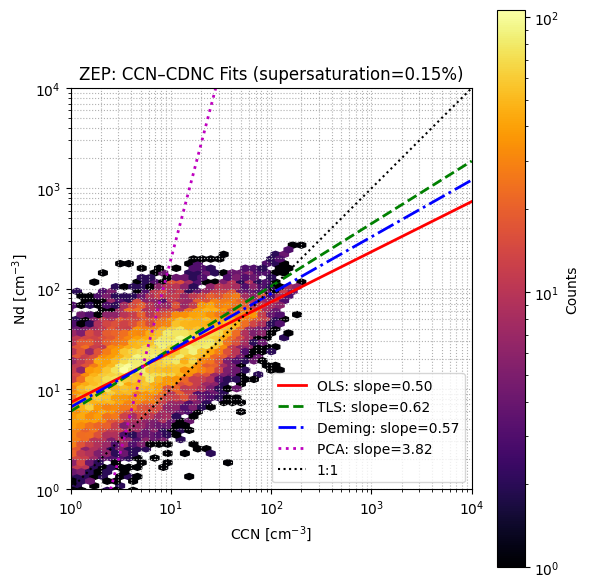

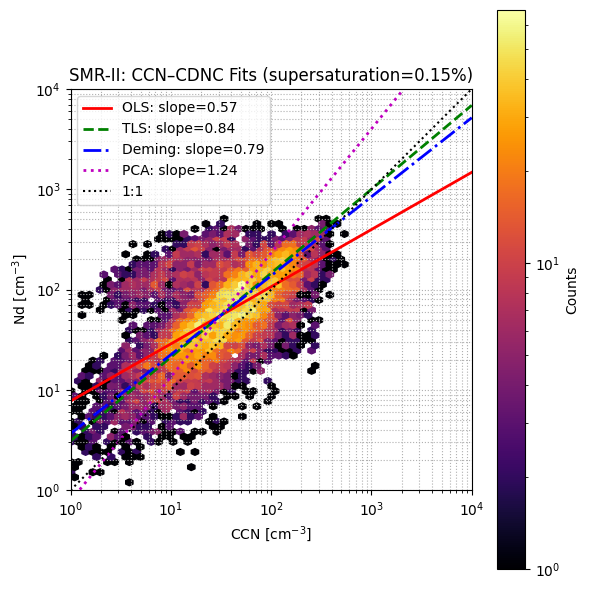

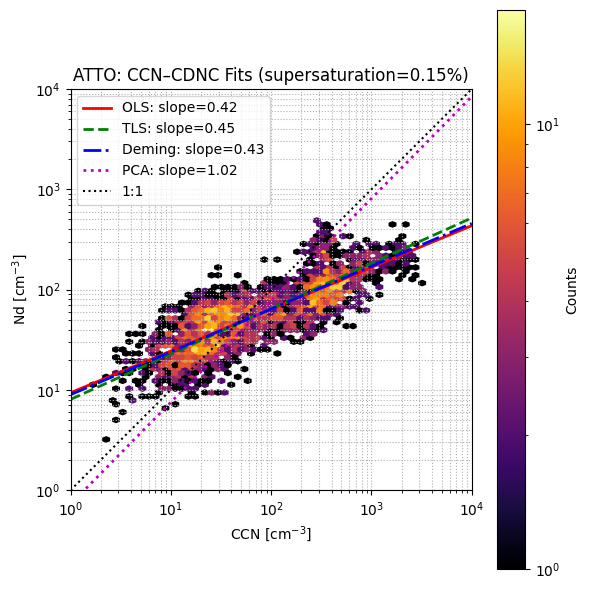

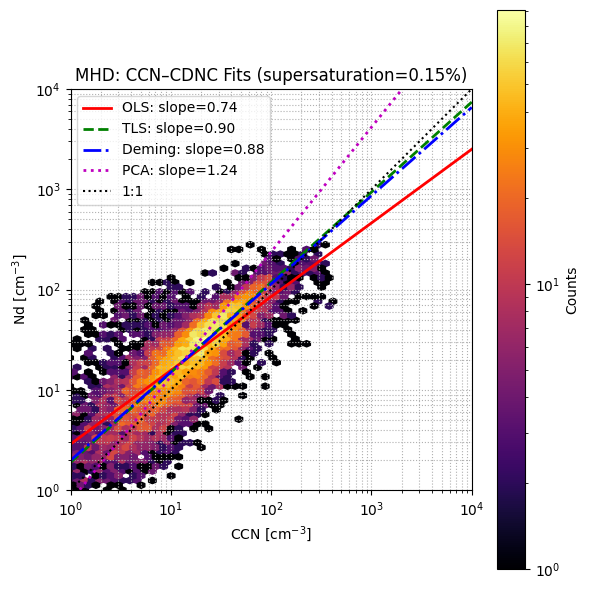

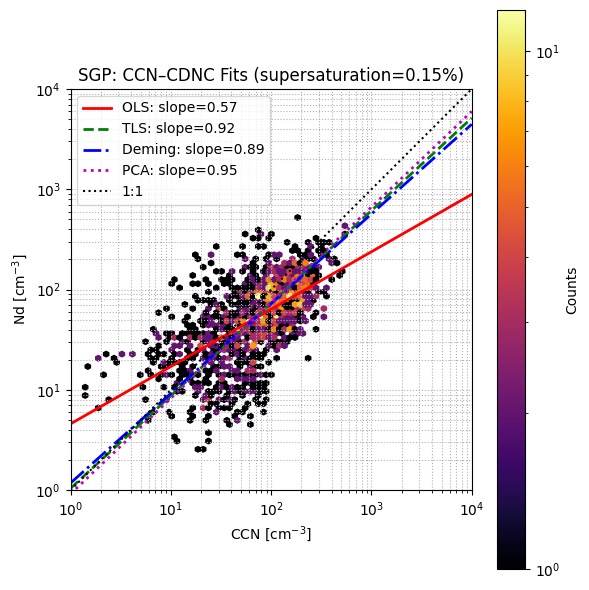

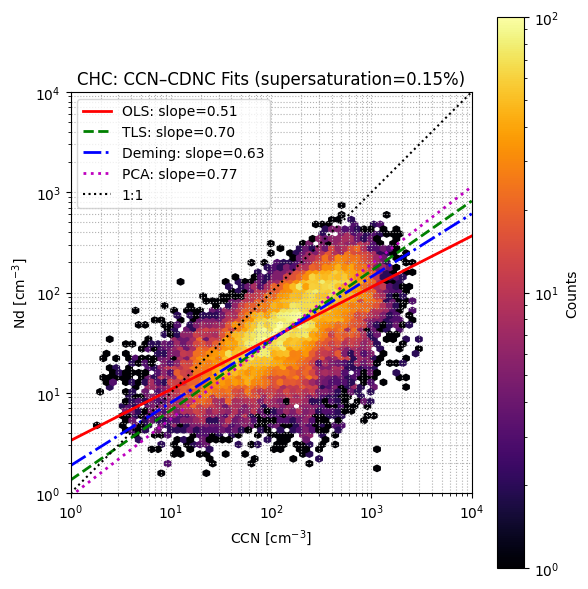

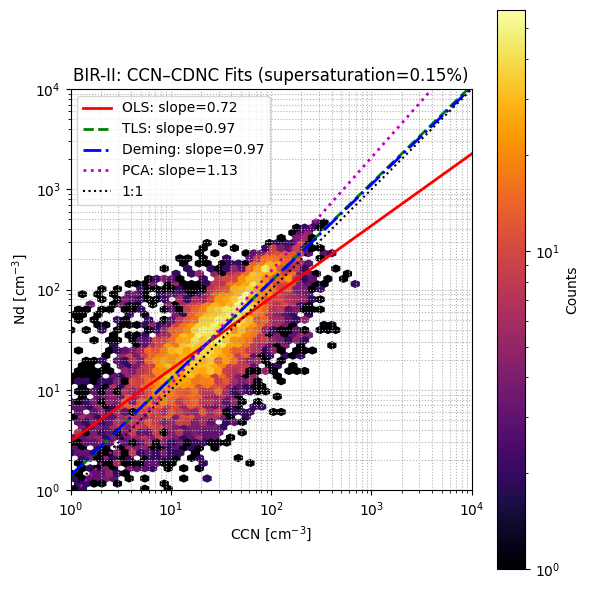

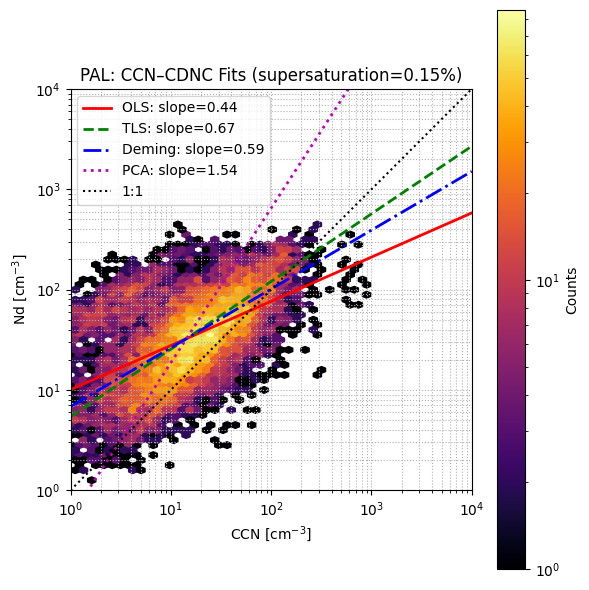

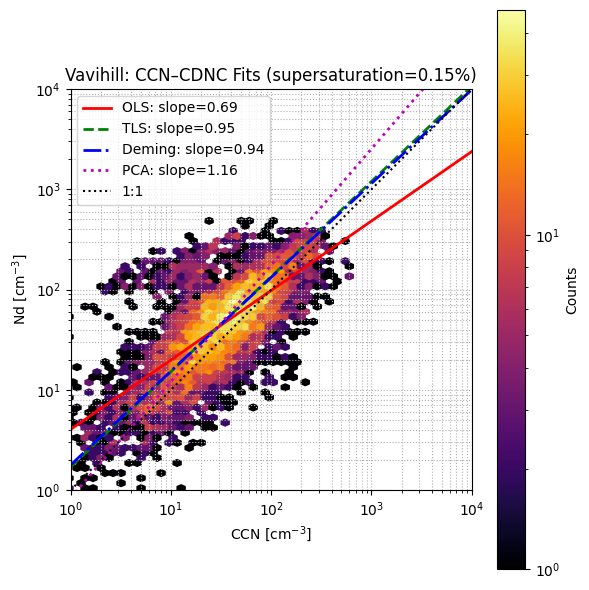

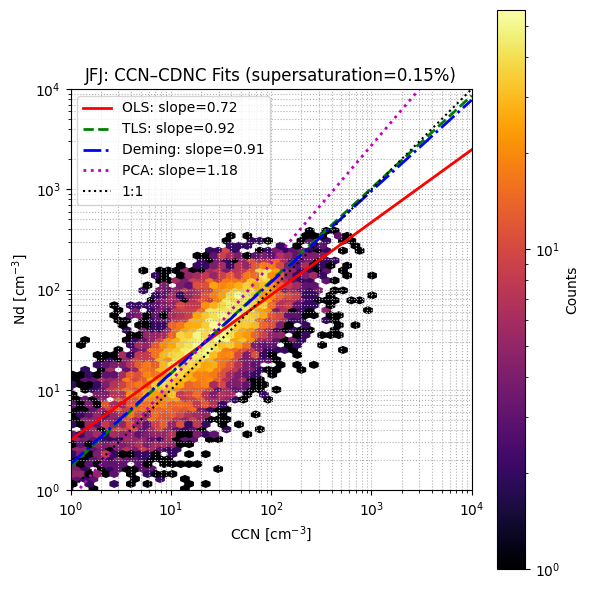

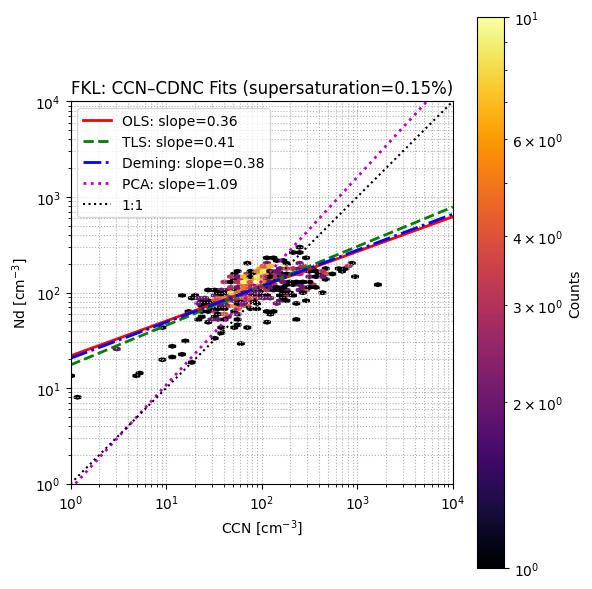

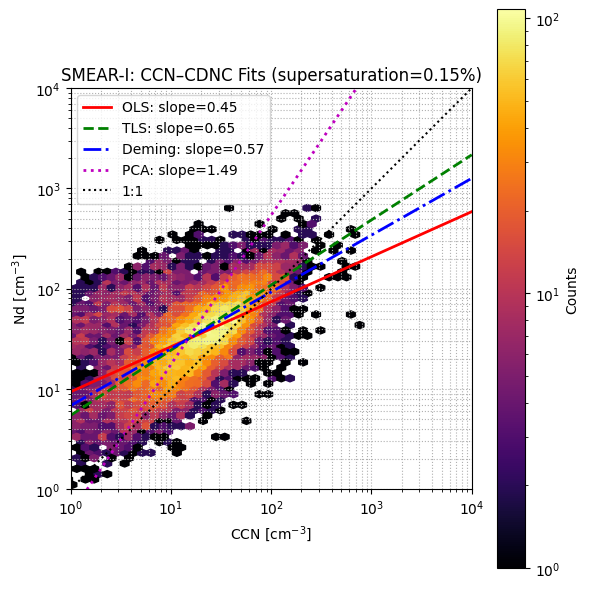

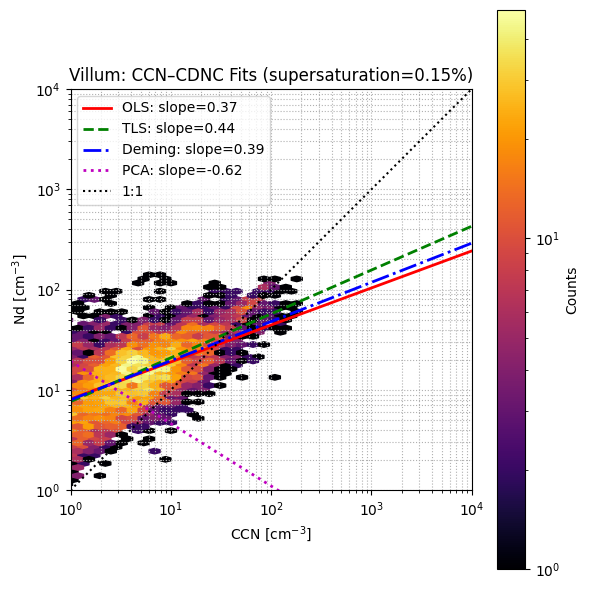

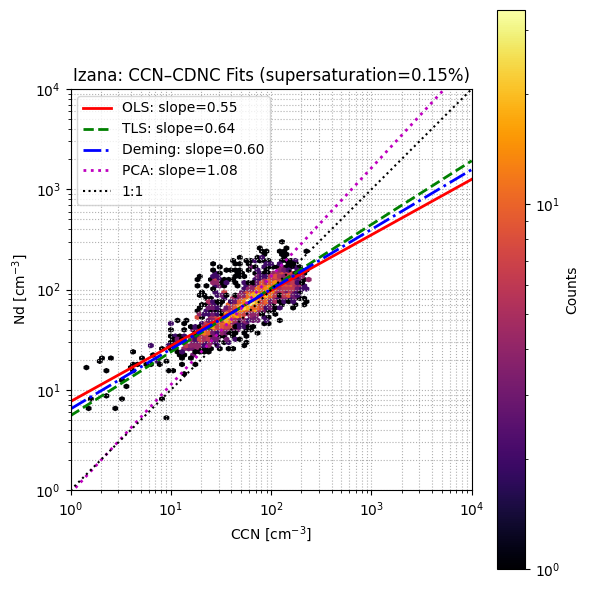

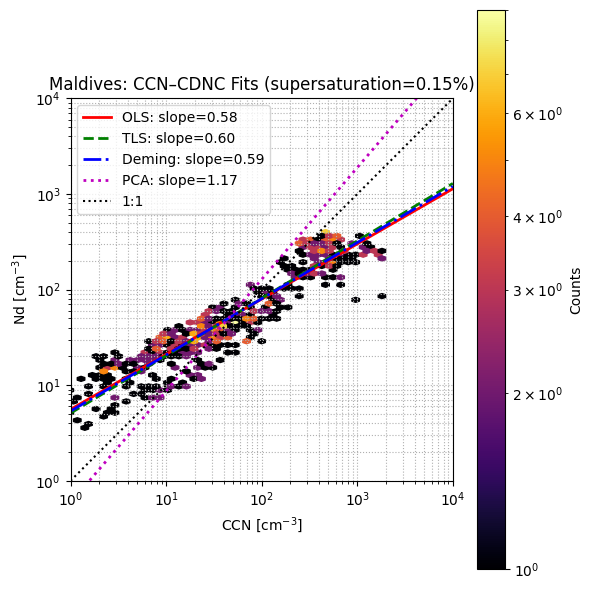

In [12]:
for station in stations:
    plot_station_fits_from_dataset(Susceptibility_all, station=station, supersaturation=0.15)

## 11 · Inspect the assembled dataset

In [13]:
Susceptibility_all

<xarray.Dataset> Size: 223kB
Dimensions:                     (station: 15, supersaturation: 7, lev: 32)
Coordinates:
  * station                     (station) <U8 480B 'ZEP' 'SMR-II' ... 'Maldives'
  * supersaturation             (supersaturation) float64 56B 0.02 0.05 ... 1.0
  * lev                         (lev) float64 256B 3.643 7.595 ... 976.3 992.6
Data variables: (12/16)
    OLS slope                   (station, supersaturation, lev) float64 27kB dask.array<chunksize=(1, 1, 32), meta=np.ndarray>
    OLS intercept               (station, supersaturation, lev) float64 27kB dask.array<chunksize=(1, 1, 32), meta=np.ndarray>
    ODR slope                   (station, supersaturation, lev) float64 27kB dask.array<chunksize=(1, 1, 32), meta=np.ndarray>
    ODR intercept               (station, supersaturation, lev) float64 27kB dask.array<chunksize=(1, 1, 32), meta=np.ndarray>
    Deming slope                (station, supersaturation, lev) float64 27kB dask.array<chunksize=(1, 1, 32), meta=np.ndarray>
    Deming intercept            (station, supersaturation, lev) float64 27kB dask.array<chunksize=(1, 1, 32), meta=np.ndarray>
    ...                          ...
    All_Level_TLS_slope         (station, supersaturation) float64 840B dask.array<chunksize=(1, 1), meta=np.ndarray>
    All_Level_TLS_intercept     (station, supersaturation) float64 840B dask.array<chunksize=(1, 1), meta=np.ndarray>
    All_Level_Deming_slope      (station, supersaturation) float64 840B dask.array<chunksize=(1, 1), meta=np.ndarray>
    All_Level_Deming_intercept  (station, supersaturation) float64 840B dask.array<chunksize=(1, 1), meta=np.ndarray>
    All_Level_PCA_slope         (station, supersaturation) float64 840B dask.array<chunksize=(1, 1), meta=np.ndarray>
    All_Level_PCA_intercept     (station, supersaturation) float64 840B dask.array<chunksize=(1, 1), meta=np.ndarray>